In [ ]:
# Install necessary libraries
!pip install seaborn matplotlib scikit-learn

# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [ ]:
# Load the dataset from the file path
data = pd.read_csv('/content/Sample - Superstore.csv', encoding='ISO-8859-1')

# Preview the first few rows of the data
data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Check for missing values
print(data.isnull().sum())

# Handle missing values if needed
data = data.dropna()  # Drop rows with missing values


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
# Convert 'Order Date' column to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Create a 'Month' column for easier grouping
data['Month'] = data['Order Date'].dt.to_period('M')


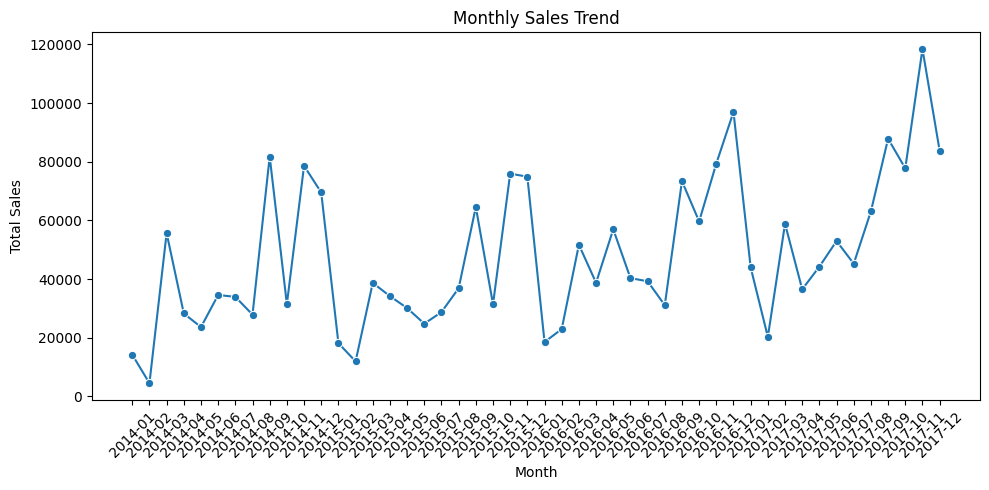

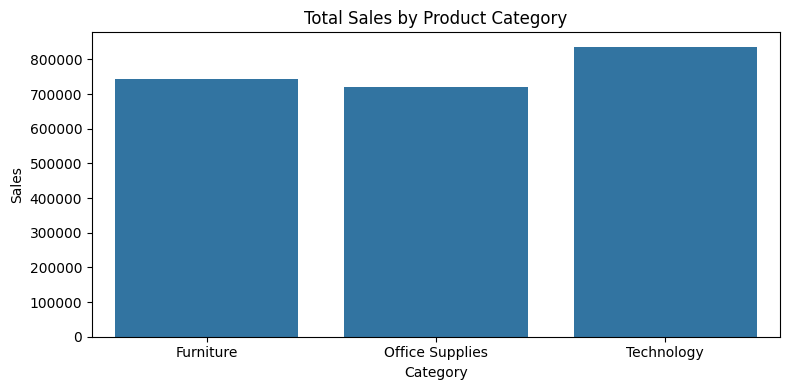

<ipython-input-21-67719dcfcfbb>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='pastel')


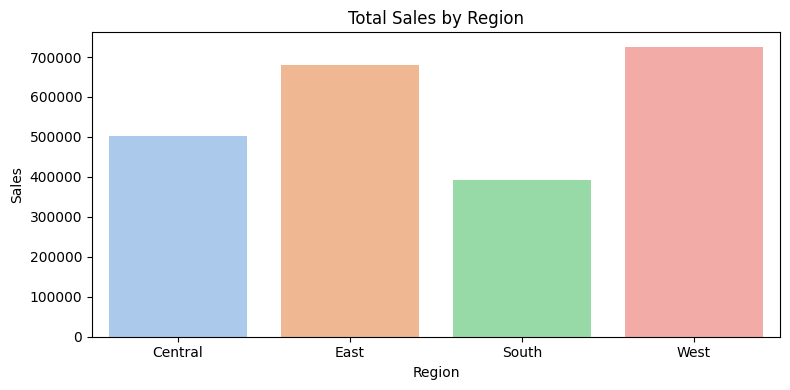

In [ ]:
# Monthly sales trend
monthly_sales = data.groupby('Month')['Sales'].sum().reset_index()
# Convert 'Month' column to string before plotting
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Plot Monthly Sales Trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sales by category
category_sales = data.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title('Total Sales by Product Category')
plt.tight_layout()
plt.show()

# Sales by region
region_sales = data.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='pastel')
plt.title('Total Sales by Region')
plt.tight_layout()
plt.show()


In [ ]:
# Calculate total sales, total orders, and average order value
total_sales = data['Sales'].sum()
total_orders = len(data)
avg_order_value = data['Sales'].mean()

# Sales by category and region
sales_by_category = data.groupby('Category')['Sales'].sum()
sales_by_region = data.groupby('Region')['Sales'].sum()

# Top-performing region
top_region = sales_by_region.idxmax()
top_region_sales = sales_by_region.max()

# Print the results
print("====== SALES KPI SUMMARY ======")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print("\nSales by Category:")
print(sales_by_category)
print("\nSales by Region:")
print(sales_by_region)
print(f"\nTop Performing Region: {top_region} (${top_region_sales:,.2f})")


====== SALES KPI SUMMARY ======
Total Sales: $2,297,200.86
Total Orders: 9994
Average Order Value: $229.86

Sales by Category:
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

Sales by Region:
Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Top Performing Region: West ($725,457.82)


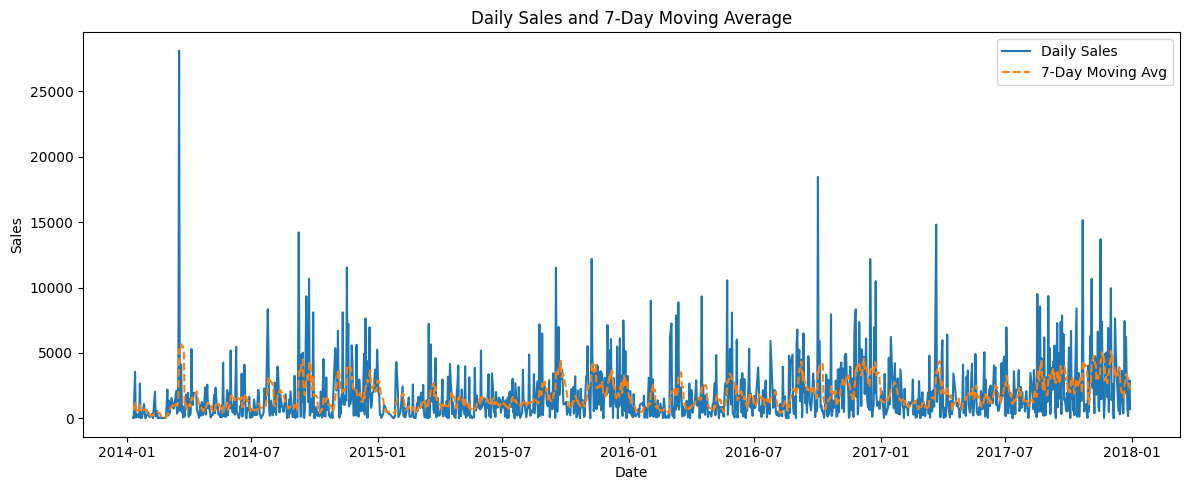

In [ ]:
# Daily sales and calculate 7-day moving average
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales['7-Day MA'] = daily_sales['Sales'].rolling(window=7).mean()

# Drop the first 6 NaN values that come from the rolling window
daily_sales = daily_sales.dropna(subset=['7-Day MA'])

# Plot daily sales and 7-day moving average
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label='Daily Sales')
plt.plot(daily_sales['Order Date'], daily_sales['7-Day MA'], label='7-Day Moving Avg', linestyle='--')
plt.title('Daily Sales and 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()


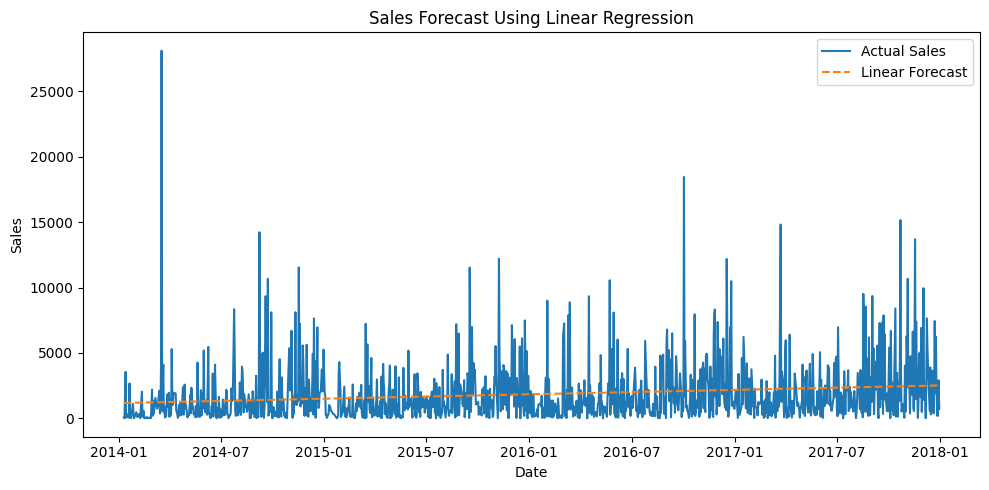

Linear Regression RMSE: 2273.42


In [ ]:
# Linear regression for sales prediction
daily_sales['Day'] = (daily_sales['Order Date'] - daily_sales['Order Date'].min()).dt.days
X = daily_sales[['Day']]  # Feature: days since the first order
y = daily_sales['Sales']  # Target: Sales

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict sales
daily_sales['Predicted Sales'] = model.predict(X)

# Plot actual vs predicted sales
plt.figure(figsize=(10, 5))
plt.plot(daily_sales['Order Date'], y, label='Actual Sales')
plt.plot(daily_sales['Order Date'], daily_sales['Predicted Sales'], label='Linear Forecast', linestyle='--')
plt.title('Sales Forecast Using Linear Regression')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# Print model performance (RMSE)
rmse = np.sqrt(mean_squared_error(y, daily_sales['Predicted Sales']))
print(f"Linear Regression RMSE: {rmse:.2f}")
